In [18]:
from pynq import Overlay, allocate, PL
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

PL.reset()

overlay = Overlay("tuto_waveprop.bit")
overlay.download()

print("IP blocks :", list(overlay.ip_dict.keys()))

IP blocks : ['fluidsimulation_comp_0', 'axi_dma_0', 'processing_system7_0']


In [19]:
fluid = overlay.fluidsimulation_comp_0
dma_recv = overlay.axi_dma_0.recvchannel

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  ap_return = Register(ap_return=0),
  frame = Register(frame=write-only)
}


In [20]:
SIZE = 102
CONTROL_REGISTER = 0x00
FRAME_REGISTER = 0x10

buffer = allocate(shape=(SIZE * SIZE,), dtype=np.int32)

def process_fpga(frame):
    dma_recv.stop()
    dma_recv.start()

    buffer[:] = 0

    dma_recv.transfer(buffer)

    fluid.write(FRAME_REGISTER, int(frame))
    fluid.write(CONTROL_REGISTER, 0x01)

    dma_recv.wait()

    return buffer.reshape((SIZE, SIZE)).copy()

(102, 102)
int32
0 188
non zero = 11


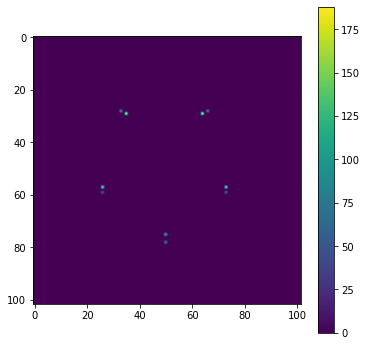

In [21]:
output = process_fpga(0)

print(output.shape)
print(output.dtype)
print(output.min(), output.max())
print("non zero =", np.count_nonzero(output))

plt.figure(figsize=(6,6))
plt.imshow(output, cmap="viridis")
plt.colorbar()
plt.show()

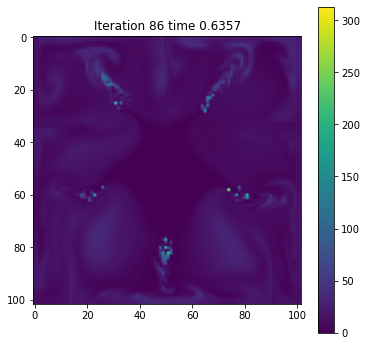

In [ ]:
for frame in range(200):
    start_time = time.time()

    output = process_fpga(frame)

    processing_time = time.time() - start_time

    clear_output(wait=True)

    plt.figure(figsize=(6,6))
    plt.imshow(output, cmap="viridis")
    plt.title(f"Iteration {frame+1} time {processing_time:.4f}")
    plt.colorbar()
    plt.show()